# Final Exam (part 2) - Computational Physics 2

### Deadline: Friday 6 June 2025 (by 23h59)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.


## 2. FFT method for fluid dynamics: 1D Shock waves

We wish to study the emergence of 1D shock waves in fluids. To do this we will modify our one-way wave equation to account for non-linear convection, i.e. we will consider that the speed of an initial Gaussian density perturbation $\rho(x, 0) = 4\,e^{-x^2}$ propagating across a periodic 1D domain is not constant, but a function of the density itself, so that our PDE becomes:

$$\frac{\partial \rho}{\partial t} + \rho\frac{\partial \rho}{\partial x} =0$$


As we see from the above equation, portions of $\rho$ with larger amplitudes will convect more rapidly, giving rise to wave steepening (i.e. to a discontinuity, which we call a **shock wave**). Without a diffusive term, the shock would become infinitely steep. Therefore, we add a diffusive (parabolic) term to our PDE so that the shock maintains a finite width. Our PDE then becomes:

$$\frac{\partial \rho}{\partial t} + \rho\frac{\partial \rho}{\partial x} =\alpha\frac{\partial^2 \rho}{\partial x^2}$$

where $\alpha$ is a diffusion constant.

---
**On our solution**

The PDE we're going to use is rewritten as:
$$\frac{\partial \rho}{\partial t} = \alpha\frac{\partial^2 \rho}{\partial x^2} -\rho\frac{\partial \rho}{\partial x}. $$

We decided to split the code into two classes: `Initializer` and `ShockSolver`. The `Initializer` class will handle the initial conditions and domain setup, while the `ShockSolver` class will implement the FFT method to solve the PDE.

---

Implement the following tasks using **python classes**:

#### **(a)** Create an appropriate domain and a reasonable time vector for the problem, and make a plot of the initial density profile.

The first class is implemented here.

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from IPython.display import HTML
from matplotlib.animation import FuncAnimation

In [2]:
# First class
class Initializer:
    """
    Class to initialize the shock wave problem.

    Parameters
    ----------
    length : int
        Length of the domain. Default is 100.
    num_points : int
        Number of points in the domain. Default is 1000.
    """
    def __init__(self, 
                 length: int = 100,
                 num_points: int = 1000):
        """
        Initializer.
        """
        # Attributes
        self.dx = length / num_points
        self.length = length
        self.num_points = num_points
        self.x = np.arange(-length/2, length/2, self.dx)

        # Initial condition
        self.initial_condition = self.ic()

    def ic(self) -> np.ndarray:
        """
        Compute the initial condition for the equation.

        Returns
        -------
        np.ndarray
            The initial condition values.
        """
        return 4 * np.exp(-self.x**2)
    
    def plot_ic(self) -> None:
        """
        Plot the initial condition.
        """
        plt.figure(figsize = (8, 5))
        plt.plot(self.x, self.initial_condition, c = 'k',
                 lw = 1.5)
        plt.title('Initial condition')
        plt.xlabel(r'$x$')
        plt.ylabel(r'$\rho(x, 0)$')
        plt.show()

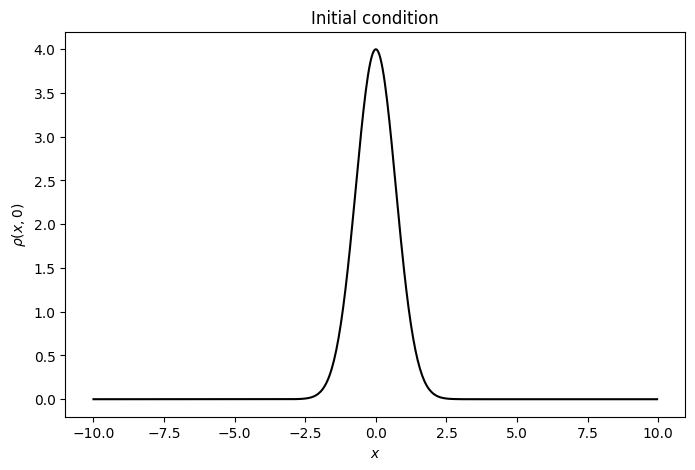

In [3]:
# Create an instace
init = Initializer(
    length = 20, 
    num_points = 500
)

# Initial condition
init.plot_ic()

The time vector is chosen in the integration part below.

#### **(b)** Write a method for the right-hand-side (RHS) of the PDE that allows you to map in and out of the Fourier domain at each time. Note that this PDE is non-linear, so the function should return the RHS in real space. **Hint:** it may be helpful to write the derivative terms in our PDE in Fourier domain.

The second complementary class is here. Everything will be implemented right away.

In [4]:
# Second class
class ShockSolver(Initializer):
    """
    Class to solve the shock wave problem using FFT.

    Parameters
    ----------
    length : int
        Length of the domain. Default is 100.
    num_points : int
        Number of points in the domain. Default is 1000.
    alpha : float
        Diffusion constant. Default is 0.1.
    """
    def __init__(self, 
                 length: int = 100,
                 num_points: int = 1000,
                 alpha: float = 0.1):
        """
        Initialize the solver.
        """
        # Parent class initializer
        super().__init__(length, num_points)
        
        # Diffusion constant
        self.alpha = alpha
        
        # Set up wavenumbers
        self.k = 2 * np.pi * np.fft.fftfreq(self.num_points, d=self.dx)
        
    def derivatives(self, rho: np.ndarray) -> tuple:
        """
        Compute spatial derivatives using FFT.
        
        Parameters
        ----------
        rho : ndarray
            Density field in real space
        
        Returns
        -------
        rho_dx : ndarray
            First derivative of density field
        rho_dx2 : ndarray
            Second derivative of density field
        """
        # Transform to Fourier space
        rho_hat = np.fft.fft(rho)
        
        # Compute derivatives
        rho_hat_dx  = 1j * self.k * rho_hat
        rho_hat_dx2 = - self.k**2 * rho_hat
        
        # Get back to real space
        rho_dx  = np.real(np.fft.ifft(rho_hat_dx))
        rho_dx2 = np.real(np.fft.ifft(rho_hat_dx2))
        
        return rho_dx, rho_dx2
    
    def rhs(self,
            t: float,
            rho: np.ndarray) -> np.ndarray:
        """
        Right-hand side of the PDE.
        
        Parameters
        ----------
        t : float
            Not used, but required for ODE solver
        rho : ndarray
            Current density field
            
        Returns
        -------
        rho_dt : ndarray
            Time derivative of density field
        """
        # Get derivatives
        rho_dx, rho_dx2 = self.derivatives(rho)
        
        # Compute convection
        convection = -rho * rho_dx
        
        # and diffusion
        diffusion = self.alpha * rho_dx2
        
        # Add them up
        rho_dt = convection + diffusion
        
        return rho_dt
    
    def solve(self,
              t_span: tuple,
              t_eval: np.ndarray = None):
        """
        Solve the shock wave equation.
        
        Parameters
        ----------
        t_span : tuple
            (t_start, t_end) time integration span
        t_eval : ndarray, optional
            Specific times to evaluate solution
            
        Returns
        -------
        solution : scipy object
            Solution object time and density field evolution
        """
        # Solve
        solution = solve_ivp(
            self.rhs, 
            t_span, 
            self.initial_condition, 
            t_eval = t_eval,
            method = 'RK45'
        )
        
        return solution

#### **(c)** Choose a reasonable value for the diffusion constant, $\alpha$, and call your function in (b). What is this function achieving so far and what space (real or Fourier) is the output in?

In [5]:
# Diffusion constant
alpha = 0.025

In [6]:
# Create an object
solver = ShockSolver(
    length = 30, 
    num_points = 500,
    alpha = alpha
)

# RHS (the time derivative)
drho_dt = solver.rhs(0, solver.initial_condition)

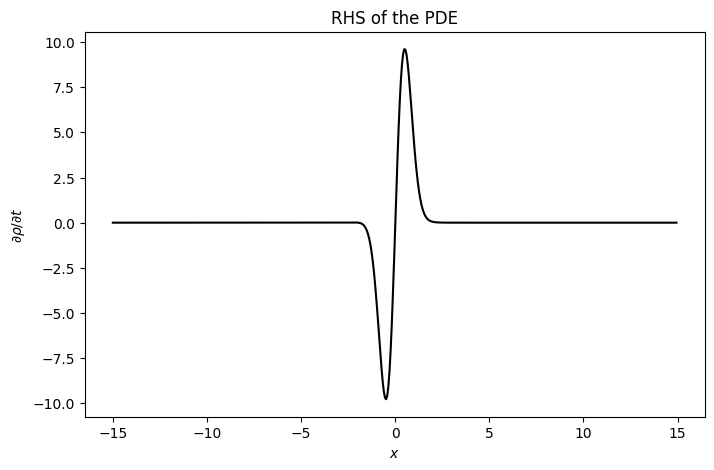

In [7]:
plt.figure(figsize = (8, 5))
plt.title('RHS of the PDE')
plt.plot(solver.x, drho_dt, c = 'k', lw = 1.5)

plt.xlabel(r'$x$')
plt.ylabel(r'$\partial \rho/\partial t$')
plt.show()

The function is achieving the time derivative of the density profile in real space since no solving has been done yet. As mentioned, the output is in real space.

#### **(d)** Find and plot the solution, $\rho(x,t)$, **using your FFT method**. For this, you need to feed a scipy ODE integrator with the function you created in (b). **Hint:** make sure you feed the correct wavenumbers to the ODE integrator.

In [8]:
# Time params
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 100)

# Solve
solution = solver.solve(
    t_span = t_span,
    t_eval = t_eval
)

In [9]:
# Extract
rho = solution.y
t = solution.t

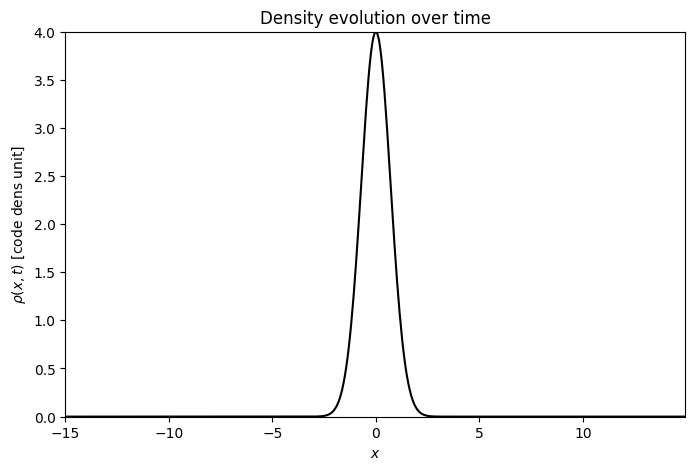

In [10]:
# Set up environment with the first solution
fig, ax = plt.subplots(figsize = (8, 5))
line, = ax.plot(solver.x, rho[:, 0], color = 'k')

ax.set_title('Density evolution over time')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\rho(x,t)$' + r' [code dens unit]')

ax.set_xlim(solver.x.min(), solver.x.max())
ax.set_ylim(rho.min(), rho.max())

# Function
def update(frame):
    line.set_ydata(rho[:, frame])
    ax.set_title('Density evolution over time, ' + r"$t = $" + f"{t[frame]:.2f} [code time unit]")
    return line,

In [11]:
# Construct the animation
ani = FuncAnimation(
    fig, 
    update, 
    frames = len(t_eval), 
    blit = True, 
    interval=99
    )

# Display
HTML(ani.to_jshtml())

#### **(e)** Repeat the above calculations for two additional $\alpha$ values (one of them should be 0). Then, make a figure (or movie) with three panels comparing the results for different $\alpha$ values and briefly discuss the role of this parameter in regulating the morphology of the shock wave.

We're going to use the same time parameters.

In [12]:
# Diffusion constants
alpha_0 = 0.0
alpha_1 = 1.0

# Objects
solver_0 = ShockSolver(
    length = 30, 
    num_points = 500,
    alpha = alpha_0
)
solver_1 = ShockSolver(
    length = 30, 
    num_points = 500,
    alpha = alpha_1
)

In [13]:
# Solve all
solution_0 = solver_0.solve(
    t_span = t_span,
    t_eval = t_eval
)
solution_1 = solver_1.solve(
    t_span = t_span,
    t_eval = t_eval
)

In [14]:
# Extract solutions
rho_0 = solution_0.y
t_0 = solution_0.t

rho_1 = solution_1.y
t_1 = solution_1.t

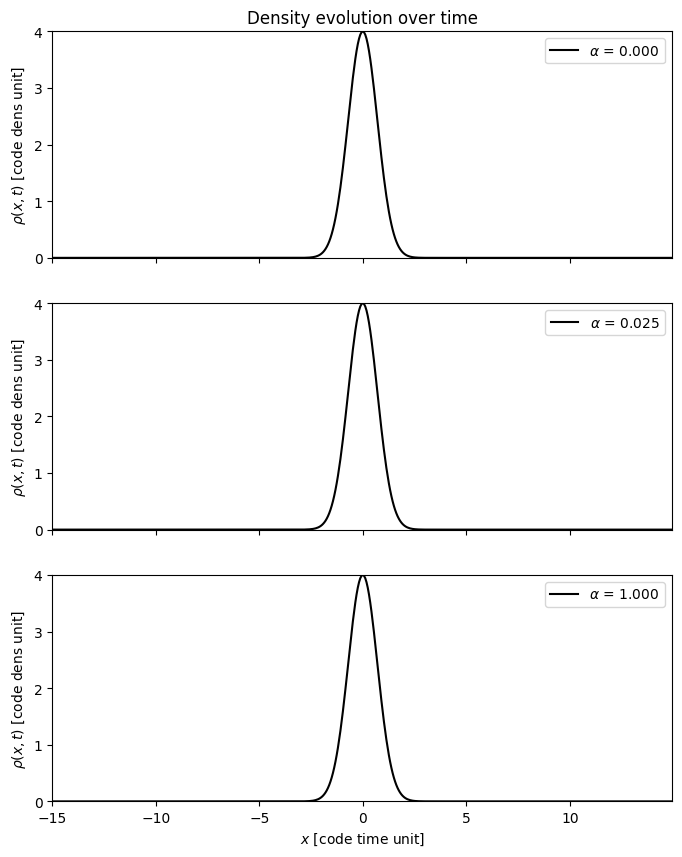

In [15]:
# Animation setup 
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize = (8, 10), sharex = True, sharey = True)

# First panel
ax0.set_title('Density evolution over time')
line0, = ax0.plot(solver_0.x, rho_0[:, 0], color = 'k', 
                  label = r'$\alpha$' + f' = {alpha_0:.3f}')
ax0.set_ylabel(r'$\rho(x,t)$' + r' [code dens unit]')

# Second panel
line1, = ax1.plot(solver.x, rho[:, 0], color = 'k', 
                  label = r'$\alpha$' + f' = {solver.alpha:.3f}')
ax1.set_ylabel(r'$\rho(x,t)$' + r' [code dens unit]')
ax1.set_xlim(solver.x.min(), solver.x.max())
ax1.set_ylim(rho.min(), rho.max())

# Third panel
line2, = ax2.plot(solver_1.x, rho_1[:, 0], color = 'k', 
                  label = r'$\alpha$' + f' = {alpha_1:.3f}')
ax2.set_ylabel(r'$\rho(x,t)$' + r' [code dens unit]')
ax2.set_xlabel(r'$x$ [code time unit]')

ax0.legend()
ax1.legend()
ax2.legend()

# Min number of frames
frames = min(len(t_0), len(t_1), len(t))

# Function for the animation
def update(frame):

    # Update the lines for each panel
    line0.set_ydata(rho_0[:, frame])
    ax0.set_title('Density at ' + r"$t = $" + f"{t_0[frame]:.2f} [code time unit]")

    line1.set_ydata(rho[:, frame])
    ax1.set_title('Density at ' + r"$t = $" + f"{t[frame]:.2f} [code time unit]")

    line2.set_ydata(rho_1[:, frame])
    ax2.set_title('Density at ' + r"$t = $" + f"{t_1[frame]:.2f} [code time unit]")
    
    return line0, line1, line2

In [16]:
# Set up the figure using the minimum number of frames
ani = FuncAnimation(
    fig, 
    update, 
    frames = frames, 
    blit = True, 
    interval = 100
)
# Display the animation
HTML(ani.to_jshtml())

The parameter $\alpha$ regulates the diffusion of the shock wave. A larger $\alpha$ leads to a wider shock wave, while $\alpha = 0$ makes the shock become infinitely steep, as we were told in the beginning.